## 3 LSTM模型

### 学习目标
* 了解LSTM内部结构及计算公式。
* 掌握Pytorch中LSTM工具的使用。
* 了解LSTM的优势与缺点。

### 1 LSTM介绍
LSTM (Long Short-Term Memory) 也称长短期记忆结构，它是传统RNN的变体，与经典RNN相比能够有效捕捉长序列之间的语义关联，缓解梯度消失或爆炸现象。 同时LSTM的结构更复杂，它的核心结构可以分为四个部分去解析：

* 遗忘门
* 输入门
* 细胞状态
* 输出门

### 2 LSTM的内部结构图

### 2.1 LSTM结构分析

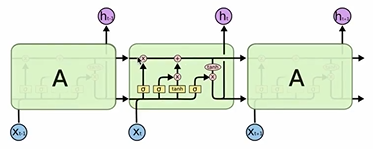

- 结构解释图

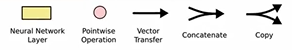

- 遗忘门部分结构图与计算公式

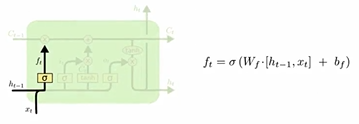

* 遗忘门结构分析：
    * 与传统RNN的内部结构计算非常相似。首先将当前时间步输入 $x(t)$ 与上一个时间步隐含状态 $h(t-1)$ 拼接，得到 $[x(t), h(t-1)]$，然后通过一个全连接层做变换，最后通过 sigmoid 函数进行激活得到 $f(t)$。我们可以将 $f(t)$ 看作是门值，好比一扇门开合的大小程度，门值都将作用在通过该扇门的张量。遗忘门门值将作用在上一层的细胞状态上，代表遗忘过去的多少信息。又因为遗忘门门值是由 $x(t)$、$h(t-1)$ 计算来的，因此整个公式意味着根据当前时间步输入和上一个时间步隐含状态 $h(t-1)$ 来决定遗忘多少上一层的细胞状态所携带的过往信息。

* 遗忘门内部结构过程演示：

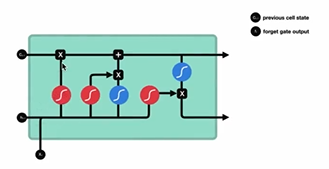

* 激活函数 sigmoid 的作用：
    * 用于帮助调节流经网络的值，sigmoid 函数将值压缩在 0 和 1 之间。

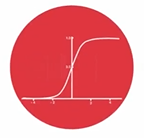

- 输入门部分结构图与计算公式

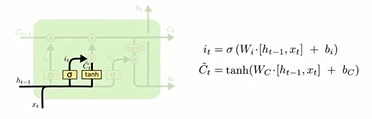

* 输入门结构分析：
    * 我们看到输入门的计算公式有两个，第一个就是产生输入门门值的公式，它和遗忘门公式几乎相同，区别只是在于它们之后要作用的目标上。这个公式意味着输入信息有多少需要进行过滤。
    * 输入门的第二个公式是与传统RNN的内部结构计算相同。对于LSTM来讲，它得到的是当前的细胞状态，而不是像经典RNN一样得到的是隐含状态。

* 输入门内部结构过程演示：

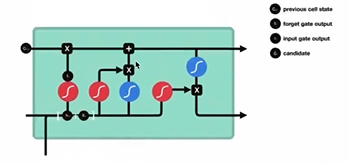

- 细胞状态更新图与计算公式：

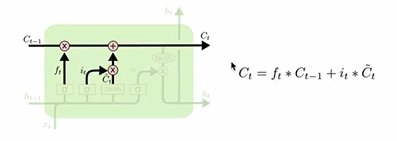

* 细胞状态更新分析：
    * 细胞更新的结构与计算公式非常容易理解。这里没有全连接层，只是将刚刚得到的遗忘门门值与上一个时间步得到的 $C(t-1)$ 相乘，再加上输入门门值与当前时间步得到的未更新 $C(t)$ 相乘的结果。最终得到更新后的 $C(t)$ 作为下一个时间步输入的一部分。整个细胞状态更新过程就是对遗忘门和输入门的应用。

* 细胞状态更新过程演示：

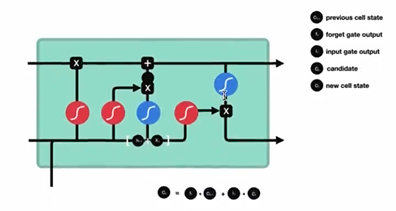

- 输出门部分结构图与计算公式

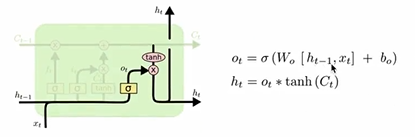

* 输出门结构分析：
    * 输出门部分的公式也是两个，第一个即是计算输出门的门值，它和遗忘门、输入门计算方式相同。第二个即是使用这个门值产生隐含状态 $h(t)$，它将作用在更新后的细胞状态 $C(t)$ 上，并做 tanh 激活，最终得到 $h(t)$ 作为下一个时间步输入的一部分。整个输出门的过程，就是为了产生隐含状态 $h(t)$。

* 输出门内部结构过程演示：

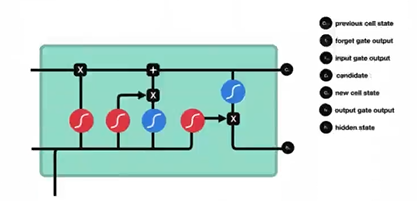

## 2.2 Bi-LSTM介绍

Bi-LSTM即双向LSTM，它没有改变LSTM本身任何的内部结构，只是将LSTM应用两次且方向不同，再将两次得到的LSTM结果进行拼接作为最终输出。

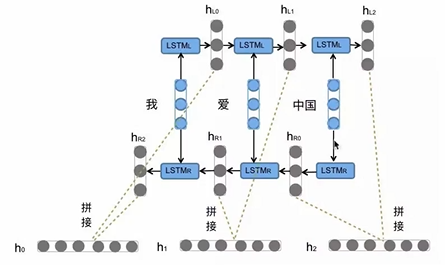

- Bi-LSTM结构分析：
  - 我们看到图中对“我爱中国”这句话或者叫这个输入序列，进行了从左到右和从右到左两次LSTM处理，将得到的结果张量进行了拼接作为最终输出。这种结构能够捕捉语言语法中一些特定的前置或后置特征，增强语义关联。但是模型参数和计算复杂度也随之增加了一倍，一般需要对语料和计算资源进行评估后决定是否使用该结构。

## 2.3 使用Pytorch构建LSTM模型

- 位置：在torch.nn工具包之中，通过torch.nn.LSTM可调用。
- nn.LSTM类初始化主要参数解释：
  - input_size: 输入张量x中特征维度的大小。
  - hidden_size: 隐层张量h中特征维度的大小。
  - num_layers: 隐含层的数量。
  - bidirectional: 是否选择使用双向LSTM，如果为True，则使用；默认不使用。

- nn.LSTM类实例化对象主要参数解释：
  - input: 输入张量x。
  - h0: 初始化的隐层张量h。
  - c0: 初始化的细胞状态张量c。

- nn.LSTM使用示例：

In [ ]:
# 定义LSTM的参数含义: (input_size, hidden_size, num_layers)
# 定义输入张量的参数含义: (sequence_length, batch_size, input_size)
# 定义隐藏层初始张量和细胞初始状态张量的参数含义:
# (num_layers * num_directions, batch_size, hidden_size)

import torch.nn as nn
import torch
rnn = nn.LSTM(5, 6, 2)
input = torch.randn(1, 3, 5)
h0 = torch.randn(2, 3, 6)
c0 = torch.randn(2, 3, 6)
output, (hn, cn) = rnn(input, (h0, c0))
output
# tensor([[ 0.0447, -0.0335,  0.1454,  0.0438,  0.0865,  0.0416],
#     [ 0.0105,  0.1923,  0.5507, -0.1742,  0.1569, -0.0548],
#     [-0.1186,  0.1835, -0.0022, -0.1388, -0.0877, -0.4007]],
#    grad_fn=<StackBackward>)

hn
# tensor([[ 0.4647, -0.2364,  0.0645, -0.3996, -0.0500, -0.0152],
#     [ 0.3852,  0.0704,  0.2103, -0.2524,  0.0243,  0.0477],
#     [ 0.2571,  0.0608,  0.2322,  0.1815, -0.0513, -0.0291]],

#     [[ 0.0447, -0.0335,  0.1454,  0.0438,  0.0865,  0.0416],
#     [ 0.0105,  0.1923,  0.5507, -0.1742,  0.1569, -0.0548],
#     [-0.1186,  0.1835, -0.0022, -0.1388, -0.0877, -0.4007]],
#    grad_fn=<StackBackward>)

cn
# tensor([[ 0.8083, -0.5500,  0.1009, -0.5806, -0.0668, -0.1161],
#     [ 0.7438,  0.0957,  0.5509, -0.7725,  0.0824,  0.0626],
#     [ 0.3131,  0.0920,  0.8359,  0.9187, -0.4826, -0.0717]],

#     [[ 0.1240, -0.0526,  0.3035,  0.1099,  0.5915,  0.0828],
#     [ 0.0203,  0.8367,  0.9832, -0.4454,  0.3917, -0.1983],
#     [-0.2976,  0.7764, -0.0074, -0.1965, -0.1343, -0.6683]],
#    grad_fn=<StackBackward>)

## 2.4 LSTM优缺点

- **LSTM优势**:
  
  LSTM的门结构能够有效减缓长序列问题中可能出现的梯度消失或爆炸，虽然并不能杜绝这种现象，但在更长的序列问题上表现优于传统RNN。

- **LSTM缺点**:
  
  由于内部结构相对较复杂，因此训练效率在同等算力下较传统RNN低很多。

---

## 3 小结

- **LSTM（Long Short-Term Memory）** 也称长短时记忆结构，它是传统RNN的变体，与经典RNN相比能够有效捕捉长序列之间的语义关联，缓解梯度消失或爆炸现象。同时LSTM的结构更复杂，它的核心结构可以分为四个部分去解析：
  - **遗忘门**
  - **输入门**
  - **输出门**
  - **细胞状态**

- **遗忘门结构分析**:
  
  与传统RNN的内部结构计算非常相似，首先将当前时间步输入到\(x(t)\)与上一个时间步隐含状态\(h(t-1)\)拼接，得到\(x(t)\)。然后通过一个全连接层做变换，最后通过sigmoid函数进行激活得到\(f(t)\)。我们可以将\(f(t)\)看作是门值，好比一扇门开合的大小程度，门值将作用在通过该扇门的张量，遗忘门门值将作用的上一层的细胞状态上，代表遗忘过去的多少信息，又因为遗忘门门值是\(h(t-1)\)决定遗忘多少上一层的细胞状态所携带的过去信息。

- 输入门结构分析：
    
    我们看到输入门的计算公式有两个，第一个就是产生输入门门值的公式，它和遗忘门公式几乎相同，区别只是在于它们之后要作用的目标上。这个公式意味着输入信息有多少需要进行过滤。输入门的第二个公式是与传统RNN的内部结构计算相同。对于LSTM来说，它得到的是当前的细胞状态，而不是像经典RNN一样得到的是隐含状态。

- 细胞状态更新分析：
  
  细胞更新的结构与计算公式非常容易理解，这里没有全连接层，只是将刚刚得到的遗忘门门值与上一个时间步得到的C(t-1)相乘，再加上输入门门值与当前时间步得到的未更新C(t)相乘的结果。最终得到更新后的C(t)作为下一个时间步输入的一部分。整个细胞状态更新过程就是对遗忘门和输入门的应用。

- 输出门结构分析：
  
  输出门部分的公式也是两个，第一个即是计算输出门的门值，它和遗忘门、输入门计算方式相同。第二个即是使用这个门值产生隐含状态h(t)，他将作用在更新后的细胞状态C(t)上，并做tanh激活，最终得到h(t)作为下一个时间步输入的一部分。整个输出门的过程，就是为了产生隐含状态h(t)。

- 什么是Bi-LSTM？
  
  Bi-LSTM即双向LSTM，它没有改变LSTM本身任何的内部结构，只是将LSTM应用两次且方向不同，再将两次得到的LSTM结果进行拼接作为最终输出。

- Pytorch中LSTM工具的使用：
  
  位置：在torch.nn工具包之中，通过torch.nn.LSTM可调用。

- LSTM优势：
  
  LSTM的门结构能够有效减少长序列问题中可能出现的梯度消失或爆炸，虽然并不能杜绝这种现象，但在更长的序列问题上表现优于传统RNN。

- LSTM缺点：
  
  由于内部结构相对较复杂，因此训练效率在同等算力下较传统RNN低很多。